<a href="https://colab.research.google.com/github/alicienty/HW2/blob/main/%D0%9B%D1%83%D0%BA%D1%8C%D1%8F%D0%BD%D1%87%D0%B8%D0%BA%D0%BE%D0%B2%D0%B0_clustering_hw.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Критерии оценки (всего 100 баллов)

| Раздел | Что проверяется | Баллы |
|--------|----------------|-------|
| **K‑Means** | Загрузка, масштабирование, цикл по K, графики, выбор K, финальная модель, визуализация, вывод силуэта | 25 |
| **DBSCAN — код** | k‑distance graph, перебор параметров, нахождение лучших, финальная модель, визуализация | 25 |
| **DBSCAN — вопросы** | 4 вопроса, каждый до 5 баллов за полноту и точность | 20 |
| **OPTICS — код** | Обучение, вывод метрик, PCA‑визуализация, reachability plot | 15 |
| **OPTICS — вопросы** | 5 вопросов, каждый до 3 баллов (развёрнутость + понимание) | 15 |

### Дополнительные требования
- Код должен быть **воспроизводимым** (фиксированный `random_state` где нужно)
- Ноутбук должен содержать **markdown‑ячейки с ответами** на вопросы
- Визуализации должны иметь подписи осей и заголовки
- Допускается использование `PCA` для визуализации, но не для обучения

---

## Формат сдачи
- **Jupyter Notebook** (`.ipynb`)
- Файл должен открываться и выполняться от начала до конца без ошибок
- Все ответы на вопросы — внутри ноутбука (markdown)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, OPTICS
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA

## Данные
**Wine Quality Dataset** (`wineqr.csv`)  
Признаки: химический состав вина (11 числовых признаков)  
Целевая переменная `quality` **не используется** — кластеризация без учителя.

In [3]:
!wget https://raw.githubusercontent.com/milaan9/Clustering-Datasets/refs/heads/master/01.%20UCI/wineqr.csv

--2026-05-04 19:34:01--  https://raw.githubusercontent.com/milaan9/Clustering-Datasets/refs/heads/master/01.%20UCI/wineqr.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 84143 (82K) [text/plain]
Saving to: ‘wineqr.csv’

wineqr.csv          100%[===================>]  82.17K  --.-KB/s    in 0.01s   

2026-05-04 19:34:01 (6.08 MB/s) - ‘wineqr.csv’ saved [84143/84143]



## Часть 1. K‑Means (обязательно)

1. Загрузите данные, удалите столбец `quality`, выполните **масштабирование** (StandardScaler).
2. Для `K` от 2 до 10:
   - Обучите K‑Means
   - Вычислите WCSS и коэффициент силуэта
3. Постройте **два графика**: метод локтя (WCSS) и средний силуэт.
4. Выберите оптимальное `K` по силуэту.
5. Обучите финальную модель K‑Means с выбранным `K`.
6. С помощью PCA (2 компоненты) визуализируйте кластеры.
7. Выведите силуэт финальной модели.

In [4]:
df = pd.read_csv('wineqr.csv')

In [5]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [6]:
X = df.drop(columns=['quality'])

In [7]:
# Масштабирование
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [8]:
range_n_clusters = range(2, 11)
wcss = []
silhouette_scores = []

for k in range_n_clusters:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    wcss.append(kmeans.inertia_)
    sil = silhouette_score(X_scaled, labels)
    silhouette_scores.append(sil)
    print(f"K={k}: WCSS={kmeans.inertia_:.1f}, Silhouette={sil:.3f}")

K=2: WCSS=14330.1, Silhouette=0.214
K=3: WCSS=12630.0, Silhouette=0.189
K=4: WCSS=11459.1, Silhouette=0.172
K=5: WCSS=10155.5, Silhouette=0.190
K=6: WCSS=9363.2, Silhouette=0.195
K=7: WCSS=8645.2, Silhouette=0.193
K=8: WCSS=8299.0, Silhouette=0.150
K=9: WCSS=7969.3, Silhouette=0.153
K=10: WCSS=7671.0, Silhouette=0.157


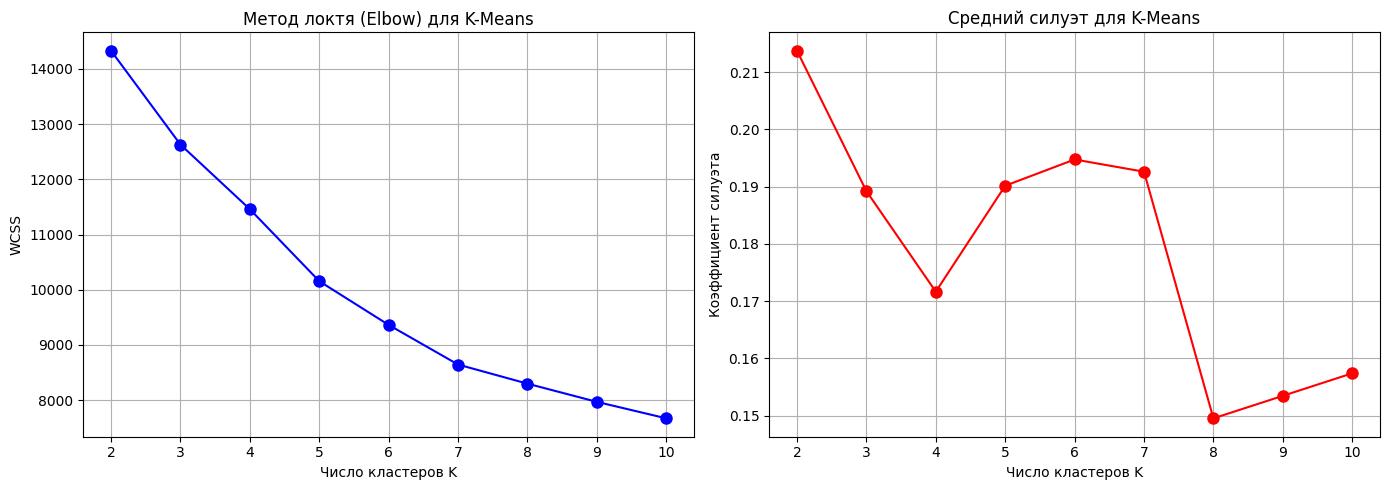

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(range_n_clusters, wcss, 'bo-', markersize=8)
ax1.set_xlabel('Число кластеров K')
ax1.set_ylabel('WCSS')
ax1.set_title('Метод локтя (Elbow) для K-Means')
ax1.grid(True)

ax2.plot(range_n_clusters, silhouette_scores, 'ro-', markersize=8)
ax2.set_xlabel('Число кластеров K')
ax2.set_ylabel('Коэффициент силуэта')
ax2.set_title('Средний силуэт для K-Means')
ax2.grid(True)

plt.tight_layout()
plt.show()

In [10]:
optimal_k = range_n_clusters[np.argmax(silhouette_scores)]
print(f"\nОптимальное число кластеров по силуэту: {optimal_k}")


Оптимальное число кластеров по силуэту: 2


In [11]:
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans_labels = kmeans_final.fit_predict(X_scaled)

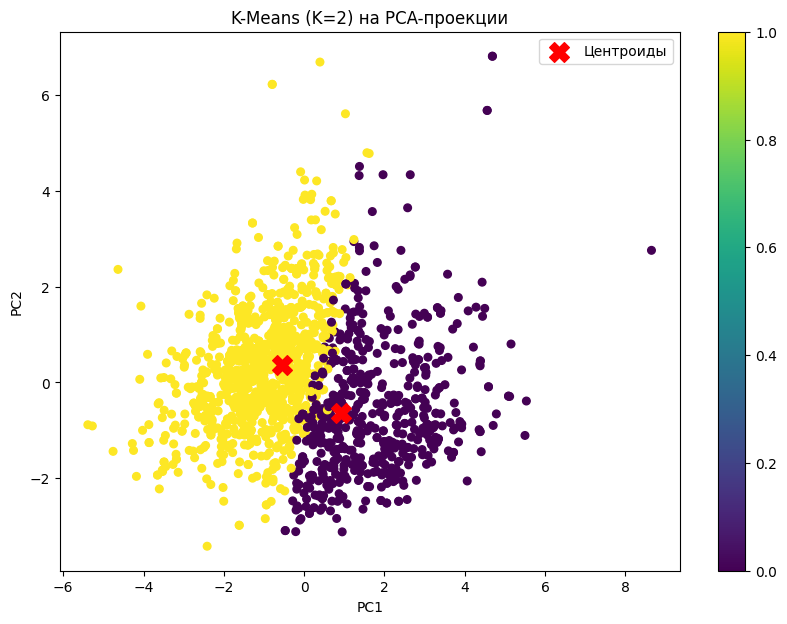

In [15]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, cmap='viridis', s=30)
plt.scatter(kmeans_final.cluster_centers_[:, 0], kmeans_final.cluster_centers_[:, 1],
            marker='X', c='red', s=200, label='Центроиды')
plt.title(f'K-Means (K={optimal_k}) на PCA-проекции')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.colorbar(scatter)
plt.show()

In [16]:
final_silhouette = silhouette_score(X_scaled, kmeans_labels)
print(f"Силуэт финальной модели: {final_silhouette:.3f}")

Силуэт финальной модели: 0.214


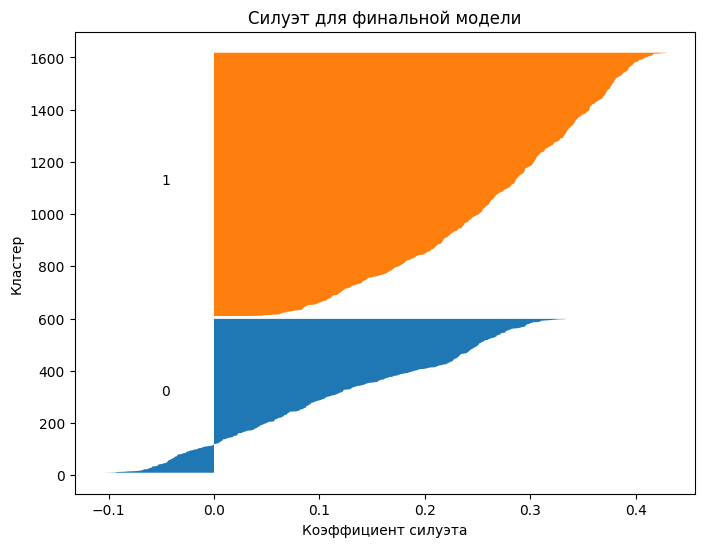

In [17]:
sample_silhouette_values = silhouette_samples(X_scaled, kmeans_labels)

y_lower = 10
plt.figure(figsize=(8, 6))

for i in range(optimal_k):
    ith_cluster_silhouette_values = sample_silhouette_values[kmeans_labels == i]
    ith_cluster_silhouette_values.sort()

    size_cluster_i = ith_cluster_silhouette_values.shape[0]
    y_upper = y_lower + size_cluster_i

    plt.fill_betweenx(np.arange(y_lower, y_upper),
                      0, ith_cluster_silhouette_values)

    plt.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
    y_lower = y_upper + 10

plt.xlabel("Коэффициент силуэта")
plt.ylabel("Кластер")
plt.title("Силуэт для финальной модели")
plt.show()

Оптимальное число кластеров по коэффициенту силуэта — 2.
График и среднее значение силуэта говорят о слабом разделении кластеров. На графике видны отрицательные значения, это говорит о частичном преекрытии кластеров.

## Часть 2. DBSCAN (самостоятельный разбор)

**Перед выполнением изучите документацию:**  
https://scikit-learn.org/stable/modules/generated/sklearn.cluster.DBSCAN.html

### Задания

1. Постройте **k‑distance graph** для `min_samples = 5, 10, 15`.  
   *Код можно взять из туториала или документации.*

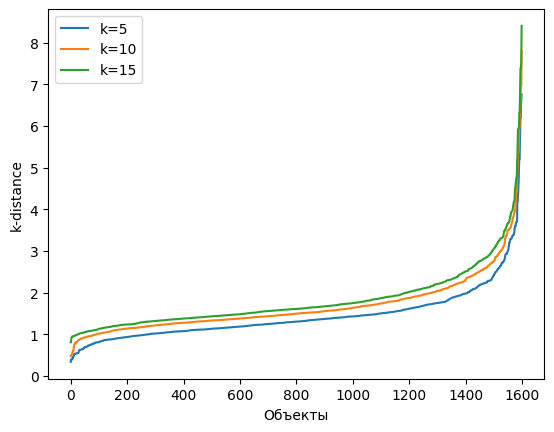

In [18]:
for k in [5, 10, 15]:
    nbrs = NearestNeighbors(n_neighbors=k).fit(X_scaled)
    distances, _ = nbrs.kneighbors(X_scaled)

    dist = np.sort(distances[:, -1])
    plt.plot(dist, label=f'k={k}')

plt.xlabel('Объекты')
plt.ylabel('k-distance')
plt.legend()
plt.show()

2. Методом перебора (`eps` от 0.3 до 1.1 с шагом 0.1, `min_samples` = 5, 10, 15) найдите параметры, дающие **максимальный силуэт** (число кластеров ≥ 2, шум не более 80% данных).

In [19]:
eps_values = np.arange(0.3, 1.2, 0.1)
min_samples_values = [5, 10, 15]

results = []

for eps in eps_values:
    for min_s in min_samples_values:
        model = DBSCAN(eps=eps, min_samples=min_s)
        labels = model.fit_predict(X_scaled)

        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

        # считаем количество шумовых документов.
        n_noise = int(np.sum(labels == -1))
        noise_part = n_noise / len(labels)

        if n_clusters >= 2:
            sil = silhouette_score(X_scaled, labels)
        else:
            sil = -1

        results.append({
            "eps": eps,
            "min_samples": min_s,
            "n_clusters": n_clusters,
            "noise_part": noise_part,
            "silhouette": sil
        })

In [20]:
df_results = pd.DataFrame(results)

In [21]:
filtered = df_results[
    (df_results["n_clusters"] >= 2) &
    (df_results["noise_part"] <= 0.8)]

In [22]:
filtered.sort_values(by="silhouette", ascending=False)

,eps,min_samples,n_clusters,noise_part,silhouette
25,1.1,10,7,0.771732,-0.223883
21,1.0,5,24,0.728580,-0.317790
24,1.1,5,18,0.587242,-0.320294


3. Обучите DBSCAN с лучшими параметрами.

In [23]:
dbscan_final = DBSCAN(
    eps=1.1,
    min_samples=10,
    metric="euclidean"
)

In [24]:
labels = dbscan_final.fit_predict(X_scaled)

4. Визуализируйте результат через PCA (точки шума — отдельным цветом/меткой).

In [25]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

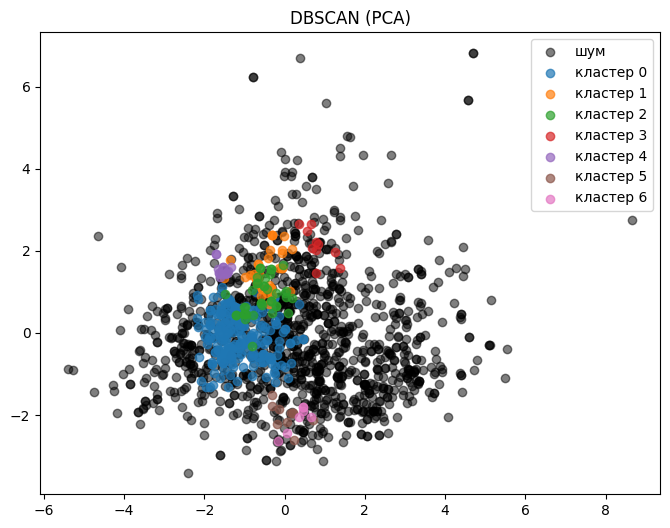

In [26]:
plt.figure(figsize=(8,6))

noise_mask = labels == -1
plt.scatter(X_pca[noise_mask, 0], X_pca[noise_mask, 1],
            c='black', label='шум', alpha=0.5)

for cluster_id in set(labels):
    if cluster_id == -1:
        continue
    plt.scatter(
        X_pca[labels == cluster_id, 0],
        X_pca[labels == cluster_id, 1],
        label=f'кластер {cluster_id}',
        alpha=0.7)

plt.title("DBSCAN (PCA)")
plt.legend()
plt.show()

5. **Ответьте на вопросы (письменно):**
   - Почему для DBSCAN критически важно масштабировать данные?
   - Что будет при слишком маленьком `eps`? Слишком большом?
   - Что означают точки с меткой `-1`?
   - Чем DBSCAN принципиально отличается от K‑Means по форме кластеров?

*   Для DBSCAN масштабирование данных критически важно, потому что этот алгоритм основан на вычислении расстояний между точками. Поэтому, если признаки имеют разные масштабы, некоторые параметры могут доминировать. Кластеры будут иметь перекрытия, могут определяться некорректно.

*   При слишком маленьком eps алгоритм практически не формирует кластеры, потому что практически не видит соседей — все точки становятся шумом. Слишком большой eps дает обратный эффект — все точки объединяются в один большой кластер.

*   Точки с меткой -1 означают шум, выбросы, которые нельзя отнести ни к одному кластеру.

*   Форма кластеров DBSCSAN в первую очередь отличается от K-means тем, что она может быть произвольной. K-means ищет пространство вокруг центроидов, DBSCAN оценивает плотность и формирует кластеры по этому параметру.



## Часть 3. OPTICS (домашнее задание)

**Изучите документацию:**  
https://scikit-learn.org/stable/modules/generated/sklearn.cluster.OPTICS.html

### Задания

1. Обучите OPTICS на тех же данных с параметрами:
   - `min_samples = 10`
   - `xi = 0.05`
   - `min_cluster_size = 0.05`



In [27]:
optics = OPTICS(
    min_samples=10,
    xi=0.05,
    min_cluster_size=0.05
)

optics_labels = optics.fit_predict(X_scaled)

2. Выведите:
   - количество найденных кластеров
   - количество шумовых точек
   - коэффициент силуэта

In [28]:
n_clusters = len(set(optics_labels)) - (1 if -1 in optics_labels else 0)
n_noise = np.sum(optics_labels == -1)

print("Количество кластеров:", n_clusters)
print("Количество шумовых точек:", n_noise)

Количество кластеров: 1
Количество шумовых точек: 0


In [29]:
mask = optics_labels != -1

if len(set(optics_labels[mask])) > 1:
    sil = silhouette_score(X_scaled[mask], optics_labels[mask])
    print("Silhouette:", round(sil, 3))
else:
    print("Силуэт посчитать нельзя (мало кластеров)")

Силуэт посчитать нельзя (мало кластеров)


3. Постройте:
   - визуализацию кластеров через PCA
   - **reachability plot** (график достижимости)

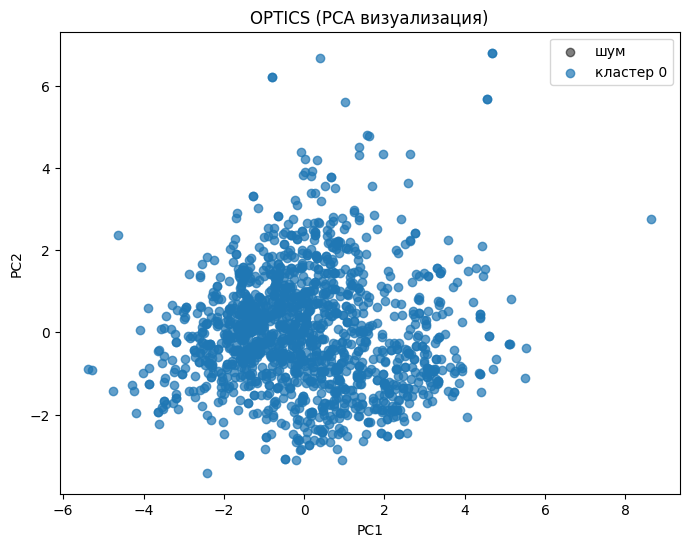

In [30]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))

noise = optics_labels == -1
plt.scatter(X_pca[noise, 0], X_pca[noise, 1],
            c='black', label='шум', alpha=0.5)

for cluster in set(optics_labels):
    if cluster == -1:
        continue
    plt.scatter(
        X_pca[optics_labels == cluster, 0],
        X_pca[optics_labels == cluster, 1],
        label=f'кластер {cluster}',
        alpha=0.7
    )

plt.title("OPTICS (PCA визуализация)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.show()

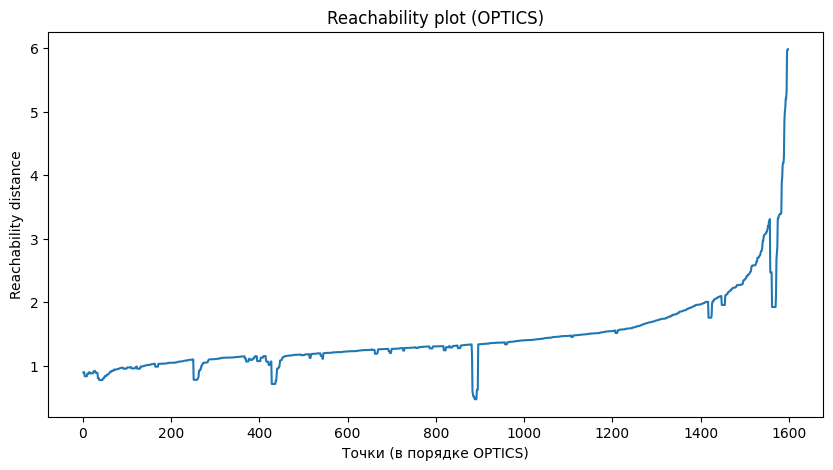

In [31]:
reachability = optics.reachability_[optics.ordering_]

plt.figure(figsize=(10,5))
plt.plot(reachability)
plt.title("Reachability plot (OPTICS)")
plt.xlabel("Точки (в порядке OPTICS)")
plt.ylabel("Reachability distance")
plt.show()

4. **Ответьте на вопросы (письменно, развёрнуто):**
   - Чем OPTICS отличается от DBSCAN? Укажите **два ключевых отличия**.
   - Что такое параметр `xi` (кси) и как он влияет на выделение кластеров?
   - В каком случае OPTICS даст результат, существенно лучший, чем DBSCAN? Приведите пример.
   - Сравните время работы DBSCAN и OPTICS на ваших данных (можно замерить через `%timeit` или `time.time()`).
   - Судя по визуализациям, какой алгоритм (K‑Means, DBSCAN, OPTICS) лучше разделил данные? Почему?

*   DBSCAN чувтсивтелен к плотности данных — данные обязательно нужно масштабировать. Кроме того, DBSCAN требует жесткой настройки параметра eps, OPTICS использует его лишь как верхнюю границу и находит кластеры разной плотности


*   Параметр xi — порог падения плотности, именно он определяет, сколько кластеров будет выделено в результате работы OPTICS. Влияет на чувствительность к перепадам плотности


*   OPTICS выигрывает, когда в данных кластеры имеют очень разную плотность, поскольку не имеет строгой зависимости от eps. Например, представим, что у нас есть датасет по собачкам. В нем представлены породы доберман, той-терьер, чихуа-хуа, йоркширский терьер, мини-пудель и шпиц. Доберман точно будет выделяться (он большой) в отдельный кластер, а остальные собачки имеют много смешанных данных, разница внутри мелких пород не настолько велика (они маленькие, расцветки похожие, нужна более точная настройка), плотность очень разная — лучше использовать OPTICS.

*   Лучше всего сработал DBSCAN, однако разбиение получилось довольно грязным. Вероятно, для этого датасета лучше подошел именно этот алгоритм, благодаря точно заданным параметрам. Вероятно, есть смысл подобрать другие параметры для OPTICS, чтобы получить лучший результат





In [32]:
import time

start = time.time()
DBSCAN(eps=1.1, min_samples=10).fit(X_scaled)
print("DBSCAN:", time.time() - start)

start = time.time()
OPTICS(min_samples=10, xi=0.05, min_cluster_size=0.05).fit(X_scaled)
print("OPTICS:", time.time() - start)

DBSCAN: 0.06423330307006836
OPTICS: 1.661867380142212


DBSCAN быстрее, поскольку не рассчитывает каждый свой шаг, не занимает много оперативной памяти